# 17. 부트스트랩 커브 · EWMA120 · 이산배당 — 전후 비교 (200개 상품)

변동성 · 상관 창을 **120 영업일(≈ 6개월)** 로 둔 MC 를 기준(전)으로, 할인 커브 · 변동성 가중 · 배당을 한꺼번에 바꾼 MC(후)를
노트북 16 과 같은 형식으로 비교한다.

| | 전: NS · HV120 · q = 0 | 후: 부트스트랩 · EWMA120 · 이산배당 |
|---|---|---|
| 커브 (드리프트 · 할인 모두) | **NS 3점 정확 적합**: 콜(0.08년) · CD91(0.25년) · 국고채 10년, FRED 월평균 (발행월 값) | **부트스트랩**: CD91(0.25년) + IRS 1 · 2 · 3 · 4 · 5 · 7 · 10 · 12 · 15 · 20년 |
| 커브 입력 시점 | 발행월 평균 — 발행일 **이후** 날도 섞임 | IRS = 발행일 **직전 영업일** 산업은행 호가 mid, CD91 = 발행월 **직전 완결월** 평균 |
| 변동성 | 각 시장 발행 전 **120 거래일**(평균 5.8개월) 단순 표준편차 × √252 | 같은 120 거래일, 가중 **λ^i** (i = 0 이 최근, **λ = 0.99**) 표준편차 × √252 |
| 상관 | 발행 전 **한국 영업일 120일** 창 안에서 쌍마다 두 시장이 모두 거래한 날의 Pearson | 같음 |
| 배당 | q = 0 | 이산배당 (노트북 16 과 동일 스케줄) |
| 나머지 | 일별 GBM · 촐레스키 · 40,000 경로 · seed=`mc_seed` | 같음 |

두 가격은 노트북 5 인라인 엔진, **같은 경로 · 같은 시드**(공통난수)다. 중간 단계(배당만 · 배당 + 커브)도 같은 경로로 가격해
**배당 · 커브 · EWMA** 의 몫을 17-5 에서 나눈다. 결과는 `result/statistics/mc_boot_curve_200*.csv` (`scratch/mc_boot_curve.py`).

## EWMA 감쇠지수 — 최대한 완만하게 (λ = 0.99)

λ 를 1 까지 올리면 단순 HV120 과 같아지므로, 감쇠를 두되 가장 완만한 쪽인 **λ = 0.99** 를 썼다.
반감기 69 거래일, 창의 가장 오래된 날 가중이 최근 날의 30% 다.
최근 42 거래일에 실리는 가중은 49% 로, 단순 HV120(35%)과 노트북 15 · 16 의 자문안 구현(span 120, λ ≈ 0.9835, 58%) 사이다.
가중치는 120일 창 안에서 재정규화한다 (pandas `ewm(alpha = 1 − λ, adjust = True)`). 상관은 가중 없이 계산한다.

## 부트스트랩 방법

- **단일 커브**: CD91 이 IRS 변동금리 지표이자 할인율 (KOFR OIS 할인 이전의 KRW 시장 관행).
- **3개월 노드**: CD91 예금으로 `DF(91/365) = 1 / (1 + CD · 91/365)`.
- **스왑 노드**: KRW IRS 는 고정 · 변동 모두 분기 지급(ACT/365, α = 0.25). 만기 T 마다 par 조건
  `s_T · α · Σ DF(t_i) + DF(T) = 1` 을 만족하는 `DF(T)` 를 brentq 로 정확히 푼다.
- **보간**: 노드 사이 `ln DF` 선형 (구간별 상수 선도금리). 6 · 8 · 9년처럼 비어 있는 만기도 이 보간으로 채운 채 다음 만기를 푼다.
- **CD91**: ECOS 일별은 인증키가 없어 FRED 월평균(= ECOS CD91 월평균, 40개월 일치 확인)을 쓰고, 발행일 이후 날이 섞이지 않도록 **직전 완결월**을 쓴다.
- **상관 창**: 한국 영업일(KRX 거래일, 연 약 245일) 120일 = 약 6개월. 3시장 **공통** 거래일 120개를 채우는 방식은 휴장일이 달라
  창이 평균 6.2개월, 최대 6.9개월로 늘어나므로 쓰지 않았다(차이는 17-5 에서 잰다).
- 단순화: T+1 결제 · 휴일 조정은 무시(1일).

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from util import file_manager as fm, plot as _plot     # import 만으로 dpi400·투명·PPT 밴드

FACE = 10000
BEF, AFT, MID, EWC, NSC = "#e07a5f", "#1f6f9c", "#2a9d8f", "#9b5de5", "#e9c46a"   # 노트북 15·16 과 같은 전·후 색
LB, LA = "before: NS · HV120 · q = 0", "after: bootstrap · EWMA120 (λ=0.99) · discrete div"
SWT = [1, 2, 3, 4, 5, 7, 10, 12, 15, 20]

d = pd.read_csv(fm.stat("mc_boot_curve_200"), encoding="utf-8-sig")
Z = pd.read_csv(fm.stat("mc_boot_curve_200_zero"), encoding="utf-8-sig")
K = pd.read_parquet(fm.CACHE / "krw_curve_fred.parquet")
d["year"] = pd.to_datetime(d.isu_dt).dt.year
d["mc_bef"], d["mc_aft"] = d.ns_h120_q0, d.bt_e120
d["err_bef"], d["err_aft"] = (d.fair - d.mc_bef) * FACE, (d.fair - d.mc_aft) * FACE

lag = (pd.to_datetime(d.isu_dt) - pd.to_datetime(d.irs_date)).dt.days
print(f"상품 {len(d)} | 발행 {d.isu_dt.min()} ~ {d.isu_dt.max()} | 만기 {d.tenor.min():.1f}~{d.tenor.max():.1f}년")
print(f"변동성 창: 각 시장 거래일 120일, 평균 {d.hv120_span_days.mean()/30.44:.1f}개월  |  "
      f"상관 창: 한국 영업일 120일, 평균 {d.corr_span_days.mean()/30.44:.1f}개월")
print(f"IRS 기준일: 발행일보다 {lag.min()}~{lag.max()}일 앞 (중앙값 {lag.median():.0f}일)  |  CD91: 발행월 직전 완결월 평균")
print(f"부트스트랩 검증: 커브로 다시 계산한 IRS par 금리 − 입력 최대 {d.reprice_bp.max():.1e}bp")
print(f"엔진 검증: 같은 엔진으로 커밋된 mc 의 정의를 계산하면 커밋 mc 와 평균 {(d.mc_q0 - d.mc_committed).abs().mean()*FACE:.1f}원 차이")

상품 200 | 발행 2015-01-05 ~ 2026-05-12 | 만기 2.0~3.0년
변동성 창: 각 시장 거래일 120일, 평균 5.8개월  |  상관 창: 한국 영업일 120일, 평균 5.9개월
IRS 기준일: 발행일보다 1~7일 앞 (중앙값 1일)  |  CD91: 발행월 직전 완결월 평균
부트스트랩 검증: 커브로 다시 계산한 IRS par 금리 − 입력 최대 1.4e-12bp
엔진 검증: 같은 엔진으로 커밋된 mc 의 정의를 계산하면 커밋 mc 와 평균 3.9원 차이


## 17-1. 커브 비교 — NS 는 1~3년 구간을 크게 높게 잡는다

전 사양의 NS 는 3개 노드(콜 0.08년 · CD 0.25년 · 국고채 10년)를 **정확히** 지나는 3모수 곡선이다(λ = 1.5).
콜과 CD 사이의 스프레드(CD 의 신용 · 기간 프리미엄, 표본 평균 19bp)가 두 달 사이의 가파른 기울기로 읽히면서
곡률항이 1~3년 구간에 **혹(hump)** 을 만든다. ELS 만기(1~3년)가 정확히 이 구간이다. 아래에서 콜 = CD 로 둔 반사실로 원인을 확인한다.

연도별 평균 (%) — CD · IRS 는 부트스트랩 입력, NS_z · BT_z 는 연속복리 제로금리
       n    CD  IRS_1Y  IRS_3Y  IRS_10Y  NS_z1  BT_z1  NS_z3  BT_z3  NS_z10  BT_z10
year                                                                               
2015  15  1.82    1.70    1.78     2.14   2.16   1.69   2.48   1.78    2.31    2.15
2016  12  1.50    1.38    1.37     1.53   1.90   1.38   2.15   1.36    1.71    1.53
2017  17  1.43    1.57    1.74     1.97   2.01   1.56   2.49   1.73    2.28    1.98
2018  23  1.66    1.84    2.03     2.22   2.17   1.83   2.60   2.02    2.50    2.22
2019  27  1.72    1.57    1.46     1.47   1.99   1.57   2.12   1.46    1.69    1.47
2020  17  1.08    0.96    1.00     1.12   1.64   0.95   2.06   1.00    1.51    1.13
2021  24  0.80    1.09    1.43     1.71   1.60   1.09   2.25   1.43    2.06    1.72
2022  19  2.11    2.87    3.14     3.02   3.57   2.86   4.37   3.13    3.32    3.00
2023  19  3.73    3.78    3.55     3.44   4.30   3.76   4.53   3.53    3.66    3.42
2024  10  3.61    

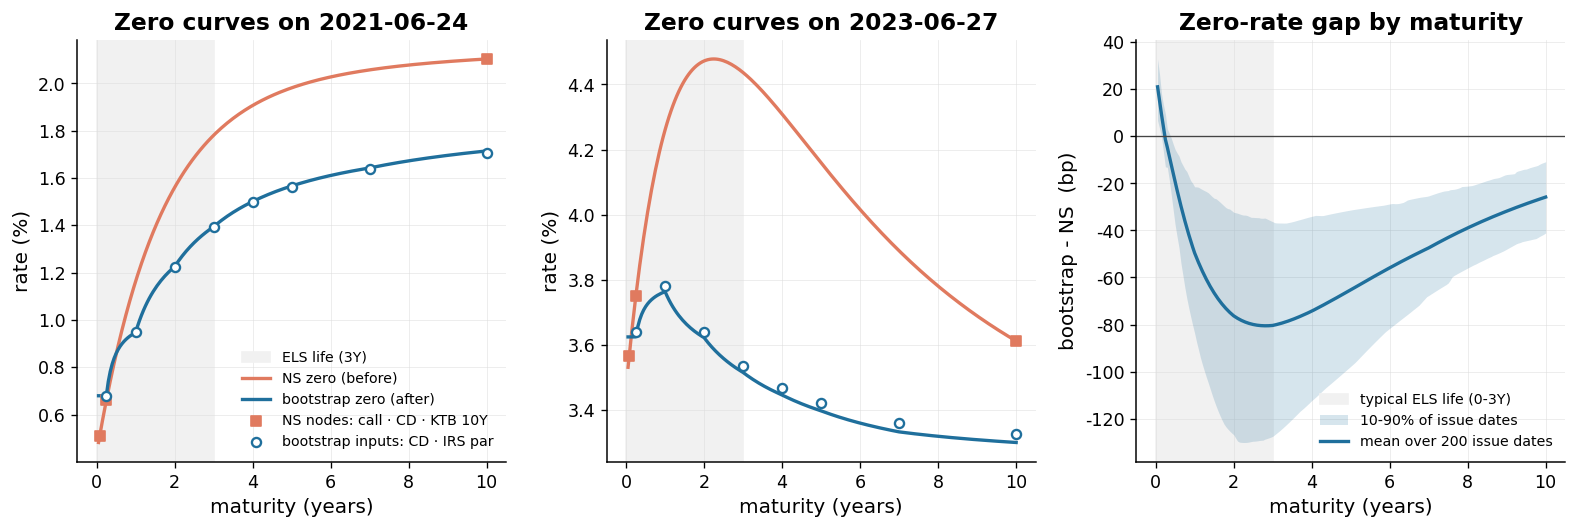

saved -> mc_boot_curves.png


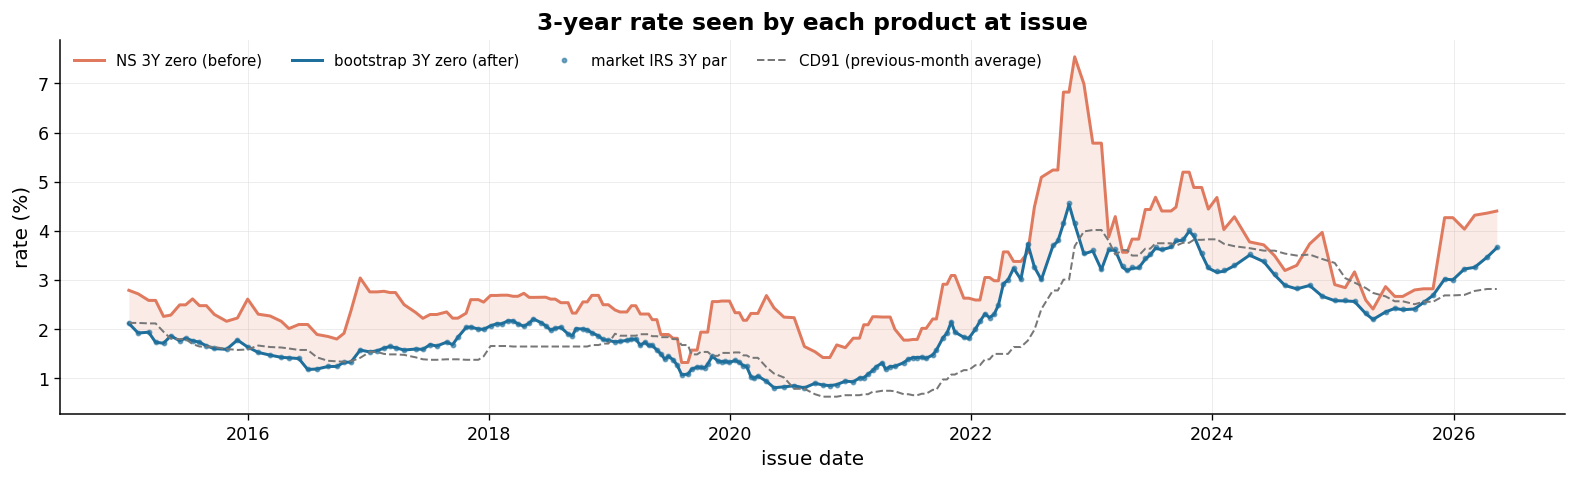

saved -> mc_boot_rate_timeseries.png


In [2]:
G = [c for c in Z.columns if c not in ("item", "isu_dt", "curve")]; tau = np.array(G, float)
zn = Z[Z.curve == "ns"].set_index("item")[G] * 100
zb = Z[Z.curve == "bt"].set_index("item")[G] * 100
dzc = (zb - zn.loc[zb.index]) * 100                                   # bp

RY = d.groupby("year").agg(n=("item", "size"), CD=("cd", "mean"), IRS_1Y=("irs_1Y", "mean"), IRS_3Y=("irs_3Y", "mean"),
                           IRS_10Y=("irs_10Y", "mean"), NS_z1=("ns_z1", "mean"), BT_z1=("bt_z1", "mean"),
                           NS_z3=("ns_z3", "mean"), BT_z3=("bt_z3", "mean"), NS_z10=("ns_z10", "mean"), BT_z10=("bt_z10", "mean"))
RY.iloc[:, 1:] *= 100
RY.to_csv(fm.stat("mc_boot_rates_by_year"))
print("연도별 평균 (%) — CD · IRS 는 부트스트랩 입력, NS_z · BT_z 는 연속복리 제로금리")
print(RY.round(2).to_string())
kk = K.reindex(pd.to_datetime(d.isu_dt).dt.to_period("M").dt.to_timestamp())
print(f"\nBOOT − NS 제로금리 차이 (bp): 0.25년 {dzc['0.25'].mean():+.0f} | 1년 {dzc['1.0'].mean():+.0f} | "
      f"3년 {dzc['3.0'].mean():+.0f} | 10년 {dzc['10.0'].mean():+.0f} | 상품 만기 {((d.bt_zT-d.ns_zT)*1e4).mean():+.0f}")
print(f"NS 3년 > NS 10년 이면서 > NS 3개월 (1~3년 혹): {((d['ns_z3']>d['ns_z10'])&(d['ns_z3']>d['ns_z0.25'])).mean()*100:.0f}% 의 날짜 | "
      f"CD − 콜 스프레드 평균 {((kk.m3-kk.call).values*100).mean():.0f}bp | NS 3년 − IRS 3년 평균 {((d.ns_z3-d.irs_3Y)*1e4).mean():+.0f}bp")

def ns_load(t, lam=1.5):
    x = np.asarray(t, float) / lam; e = np.exp(-x)
    return np.stack([np.ones_like(x), (1 - e) / x, (1 - e) / x - e], -1)
A3 = ns_load([0.08, 0.25, 10.0])
cf = np.array([ns_load(3.0) @ np.linalg.solve(A3, [m, m, y]) for m, y in kk[["m3", "y10"]].values])
print(f"반사실 (콜 = CD, 스프레드 0): NS 3년 평균 {d.ns_z3.mean()*100:.2f}% → {cf.mean():.2f}%  "
      f"(시장 IRS 3년 {d.irs_3Y.mean()*100:.2f}%, 부트스트랩 3년 {d.bt_z3.mean()*100:.2f}%)  → 혹의 원인은 콜−CD 스프레드")

def near(ds):
    return d.loc[(pd.to_datetime(d.isu_dt) - pd.Timestamp(ds)).abs().idxmin()]

fig, ax = plt.subplots(1, 3, figsize=(13.333, 4.6))
for a, ds in zip(ax[:2], ["2021-07-01", "2023-07-01"]):
    r = near(ds); k = K.asof(pd.Timestamp(r.isu_dt))
    a.axvspan(0, r.tenor, color="#f1f1f1", zorder=0, label=f"ELS life ({r.tenor:.0f}Y)")
    a.plot(tau, zn.loc[r["item"]], color=BEF, lw=2, label="NS zero (before)")
    a.plot(tau, zb.loc[r["item"]], color=AFT, lw=2, label="bootstrap zero (after)")
    a.scatter([0.08, 0.25, 10], [k.call, k.m3, k.y10], marker="s", s=36, color=BEF, zorder=5,
              label="NS nodes: call · CD · KTB 10Y")
    a.scatter([91 / 365] + [t for t in SWT if t <= 10], [r.cd * 100] + [r[f"irs_{t}Y"] * 100 for t in SWT if t <= 10],
              marker="o", s=30, facecolor="white", edgecolor=AFT, lw=1.4, zorder=6, label="bootstrap inputs: CD · IRS par")
    a.set_xlabel("maturity (years)"); a.set_ylabel("rate (%)"); a.set_title(f"Zero curves on {r.isu_dt}")
    a.grid(color="#dddddd", lw=.5, alpha=.6)
ax[0].legend(fontsize=8.5, loc="lower right")
m, lo, hi = dzc.mean(), dzc.quantile(.1), dzc.quantile(.9)
ax[2].axvspan(0, 3, color="#f1f1f1", zorder=0, label="typical ELS life (0-3Y)")
ax[2].fill_between(tau, lo, hi, color=AFT, alpha=.18, lw=0, label="10-90% of issue dates")
ax[2].plot(tau, m, color=AFT, lw=2, label="mean over 200 issue dates")
ax[2].axhline(0, color="#444", lw=.8)
ax[2].set_xlabel("maturity (years)"); ax[2].set_ylabel("bootstrap - NS  (bp)"); ax[2].set_title("Zero-rate gap by maturity")
ax[2].legend(fontsize=8.5, loc="lower right"); ax[2].grid(color="#dddddd", lw=.5, alpha=.6)
fig.tight_layout(); fig.savefig(fm.image("mc_boot_curves")); plt.show()
print("saved ->", fm.image("mc_boot_curves").name)

x = pd.to_datetime(d.isu_dt)
fig, ax = plt.subplots(figsize=(13.333, 4.2))
ax.fill_between(x, d.bt_z3 * 100, d.ns_z3 * 100, color=BEF, alpha=.15, lw=0)
ax.plot(x, d.ns_z3 * 100, color=BEF, lw=1.8, label="NS 3Y zero (before)")
ax.plot(x, d.bt_z3 * 100, color=AFT, lw=1.8, label="bootstrap 3Y zero (after)")
ax.plot(x, d.irs_3Y * 100, "o", ms=2.5, color=AFT, alpha=.6, label="market IRS 3Y par")
ax.plot(x, d.cd * 100, color="#777777", lw=1.2, ls="--", label="CD91 (previous-month average)")
ax.set_xlabel("issue date"); ax.set_ylabel("rate (%)"); ax.set_title("3-year rate seen by each product at issue")
ax.grid(color="#dddddd", lw=.5, alpha=.6); ax.legend(fontsize=9, ncol=4, loc="upper left")
fig.tight_layout(); fig.savefig(fm.image("mc_boot_rate_timeseries")); plt.show()
print("saved ->", fm.image("mc_boot_rate_timeseries").name)

## 17-2. 전체 요약 — 오차가 줄었는가

`공정가 − MC` 가 0 에 가까울수록 MC 가 공정가를 잘 맞춘 것이다. 음수는 MC 과대평가.

In [3]:
def summ(e, mc):
    return {"mean_err_KRW": e.mean(), "median_err_KRW": e.median(), "MAE_KRW": e.abs().mean(),
            "RMSE_KRW": np.sqrt((e ** 2).mean()), "MAPE%": (e.abs() / (d.fair * FACE)).mean() * 100,
            "R2": r2_score(d.fair, mc)}


S = pd.DataFrame({"before: NS · HV120 · q=0": summ(d.err_bef, d.mc_bef),
                  "after: bootstrap · EWMA120 · div": summ(d.err_aft, d.mc_aft)}).T
S.loc["after - before"] = S.iloc[1] - S.iloc[0]
S.to_csv(fm.stat("mc_boot_summary"))
print(S.round(3).to_string())
better = (d.err_aft.abs() < d.err_bef.abs()).mean()
print(f"\n|오차| 가 줄어든 상품 {better*100:.1f}%  |  MC 가격 변화 (후 − 전) 평균 "
      f"{((d.mc_aft - d.mc_bef) * FACE).mean():+,.0f}원, 표준편차 {((d.mc_aft - d.mc_bef) * FACE).std():,.0f}원")
print(f"입력 평균 변동성: HV120 {d.hv120.mean()*100:.2f}% → EWMA120 {d.ew120.mean()*100:.2f}%  "
      f"(상품별 |차| {(d.ew120 - d.hv120).abs().mean()*100:.2f}%p)  |  상관(영업일 120일) {d.rho120.mean():.3f}")

                                  mean_err_KRW  median_err_KRW  MAE_KRW  RMSE_KRW  MAPE%     R2
before: NS · HV120 · q=0              -517.372        -548.136  640.981   751.995  7.066 -1.586
after: bootstrap · EWMA120 · div      -376.137        -451.007  588.338   706.682  6.464 -1.284
after - before                         141.235          97.129  -52.643   -45.313 -0.602  0.302

|오차| 가 줄어든 상품 77.0%  |  MC 가격 변화 (후 − 전) 평균 -141원, 표준편차 157원
입력 평균 변동성: HV120 18.40% → EWMA120 18.46%  (상품별 |차| 0.78%p)  |  상관(영업일 120일) 0.345


## 17-3. `(공정가 − MC)` 히스토그램 — 전후 겹침

노트북 15 · 16 과 같은 형식이다. 두 분포는 같은 구간(bin)을 쓴다.

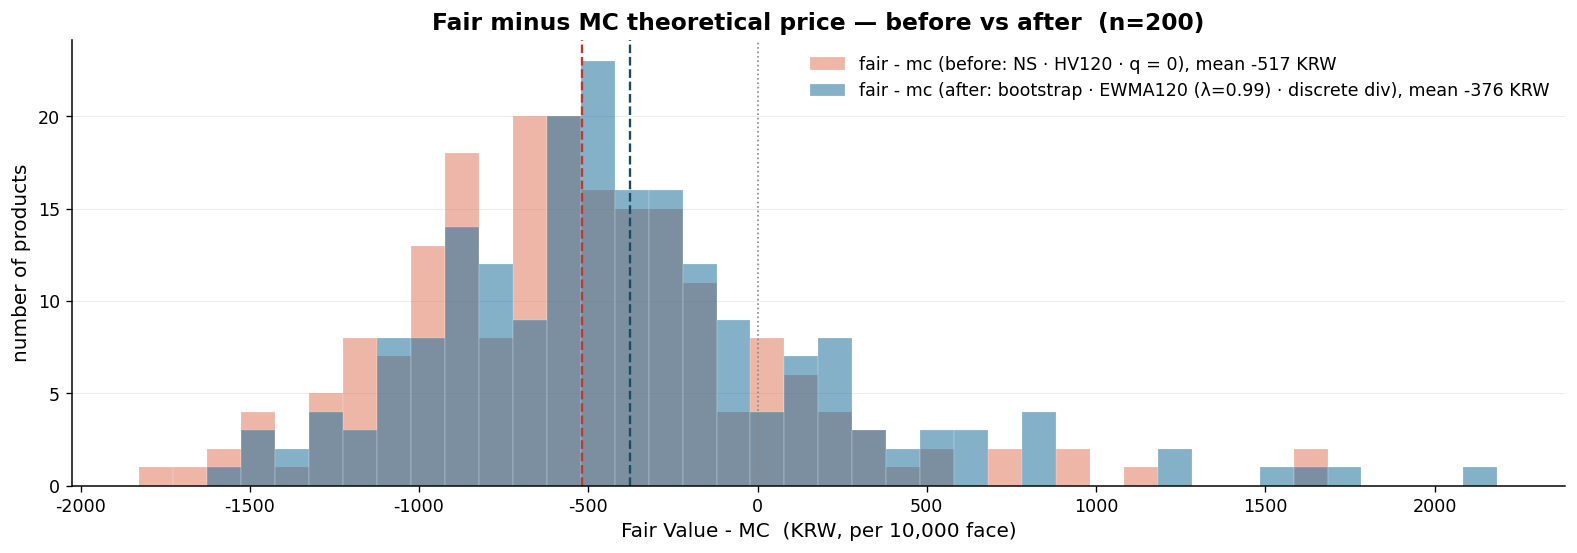

fair-mc 전 -517 | 후 -376 | 편향 변화 +141 KRW
saved -> mc_boot_fair_minus_mc_hist.png


In [4]:
e_b, e_a = d.err_bef, d.err_aft
bins = np.linspace(min(e_b.min(), e_a.min()), max(e_b.max(), e_a.max()), 41)
fig, ax = plt.subplots(figsize=(13.333, 4.8))
ax.hist(e_b, bins=bins, color=BEF, alpha=.55, edgecolor="white", lw=.2, label=f"fair - mc ({LB}), mean {e_b.mean():,.0f} KRW")
ax.hist(e_a, bins=bins, color=AFT, alpha=.55, edgecolor="white", lw=.2, label=f"fair - mc ({LA}), mean {e_a.mean():,.0f} KRW")
ax.axvline(e_b.mean(), color="#c0392b", lw=1.4, ls="--"); ax.axvline(e_a.mean(), color="#1c4a5f", lw=1.4, ls="--")
ax.axvline(0, color="#888", lw=1, ls=":")
ax.set_xlabel("Fair Value - MC  (KRW, per 10,000 face)"); ax.set_ylabel("number of products")
ax.set_title(f"Fair minus MC theoretical price — before vs after  (n={len(d)})")
ax.grid(axis="y", color="#dddddd", lw=0.5, alpha=0.6); ax.legend(loc="upper right")
fig.tight_layout(); fig.savefig(fm.image("mc_boot_fair_minus_mc_hist")); plt.show()
print(f"fair-mc 전 {e_b.mean():,.0f} | 후 {e_a.mean():,.0f} | 편향 변화 {e_a.mean()-e_b.mean():+,.0f} KRW")
print("saved ->", fm.image("mc_boot_fair_minus_mc_hist").name)

## 17-4. 가격구간별 오차 · MAPE — 전후

(200개라 구간당 약 33개 — 구간별 값은 노이즈가 있다.)

                 n  fair_mean  err_bef  err_aft  MAPE_bef  MAPE_aft
price_seg                                                          
(0.799, 0.885]  34       0.86 -1017.21  -834.19     13.33     12.00
(0.885, 0.914]  33       0.90  -830.31  -656.57      9.22      7.91
(0.914, 0.934]  33       0.92  -579.69  -424.69      7.94      7.05
(0.934, 0.952]  33       0.94  -435.10  -322.36      5.69      4.98
(0.952, 0.98]   33       0.97  -255.73  -174.95      4.22      3.91
(0.98, 1.04]    34       1.00    12.88   153.76      1.97      2.87


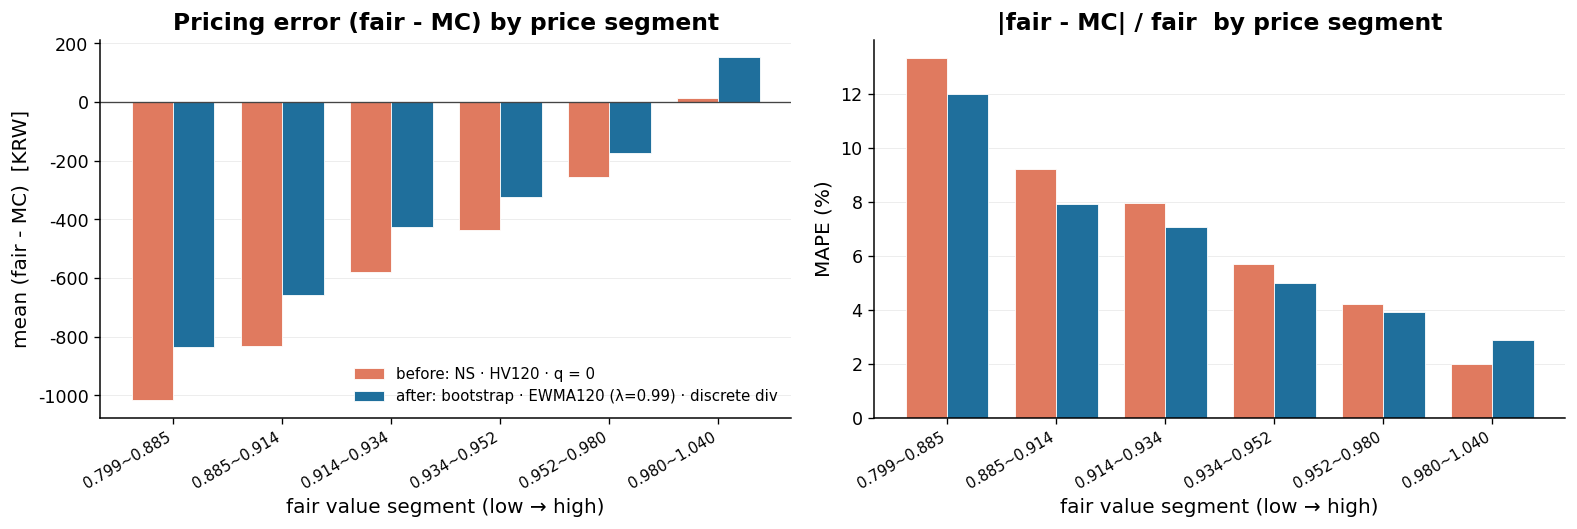

구간 기울기 (최안전 − 최위험 구간 평균오차): 전 1,030원 → 후 988원
saved -> mc_boot_err_by_price_seg.png


In [5]:
d["price_seg"] = pd.qcut(d.fair, 6)
d["ape_bef"] = d.err_bef.abs() / (d.fair * FACE) * 100
d["ape_aft"] = d.err_aft.abs() / (d.fair * FACE) * 100
g = d.groupby("price_seg", observed=True).agg(
    n=("fair", "size"), fair_mean=("fair", "mean"), err_bef=("err_bef", "mean"), err_aft=("err_aft", "mean"),
    MAPE_bef=("ape_bef", "mean"), MAPE_aft=("ape_aft", "mean"))
g.to_csv(fm.stat("mc_boot_by_price_seg"))
print(g.round(2).to_string())

xs = np.arange(len(g)); xl = [f"{iv.left:.3f}~{iv.right:.3f}" for iv in g.index]; w = .38
fig, ax = plt.subplots(1, 2, figsize=(13.333, 4.6))
for a, cb, ca, yl, tt in [(ax[0], "err_bef", "err_aft", "mean (fair - MC)  [KRW]", "Pricing error (fair - MC) by price segment"),
                          (ax[1], "MAPE_bef", "MAPE_aft", "MAPE (%)", "|fair - MC| / fair  by price segment")]:
    a.bar(xs - w/2, g[cb].values, w, color=BEF, edgecolor="white", linewidth=.5, label=LB)
    a.bar(xs + w/2, g[ca].values, w, color=AFT, edgecolor="white", linewidth=.5, label=LA)
    a.axhline(0, color="#444", lw=.8)
    a.set_xticks(xs); a.set_xticklabels(xl, rotation=30, fontsize=9, ha="right")
    a.set_ylabel(yl); a.set_xlabel("fair value segment (low → high)"); a.set_title(tt)
    a.grid(axis="y", color="#dddddd", lw=0.5, alpha=0.6)
ax[0].legend(fontsize=9, loc="lower right")
fig.tight_layout(); fig.savefig(fm.image("mc_boot_err_by_price_seg")); plt.show()
print(f"구간 기울기 (최안전 − 최위험 구간 평균오차): 전 {g.err_bef.iloc[-1]-g.err_bef.iloc[0]:,.0f}원 → "
      f"후 {g.err_aft.iloc[-1]-g.err_aft.iloc[0]:,.0f}원")
print("saved ->", fm.image("mc_boot_err_by_price_seg").name)

## 17-5. 무엇이 가격을 움직였나 — 배당 · 커브 · EWMA

전 → 후를 같은 경로로 한 단계씩 바꿔 나눈다: **배당** → **커브** (할인 몫 + 드리프트 몫) → **HV120 → EWMA120**.
커브의 할인 몫은 드리프트를 NS 로 둔 채 할인만 부트스트랩으로 바꾼 가격이고, 드리프트 몫은 나머지다.
위험중립 가격에서는 같은 금리가 선도가격(드리프트)과 할인에 함께 들어가므로, 금리가 낮아지면 할인은 가격을 올리고
선도가격 하락은 조기상환 확률을 낮춰 가격을 내린다.

=== 단계별 (같은 경로) ===
                                           mean_err_KRW  MAE_KRW
before: NS · HV120 · q=0                         -517.4    641.0
+ dividends: NS · HV120 · div                    -377.1    571.0
+ curve: bootstrap · HV120 · div                 -383.7    578.9
+ EWMA = after: bootstrap · EWMA120 · div        -376.1    588.3

=== MC 가격 변화 분해 (원, 음수 = MC 가 싸짐) ===
                  mean  mean |Δ|    std
dividends       -140.2     140.3   93.8
curve: discount   56.5      56.8   44.8
curve: drift     -49.9      50.2   41.9
curve: net         6.6      14.4   22.9
HV120 → EWMA120   -7.6      71.4  114.4
total           -141.2     151.9  157.0
단기 끝 민감도 (CD 노드 유무): 평균 +0.7원, 상품별 |Δ| 1.8원
상관 정의 (영업일 120일 − 3시장 공통거래일 120개): 평균 +0.2원, 상품별 |Δ| 4.1원


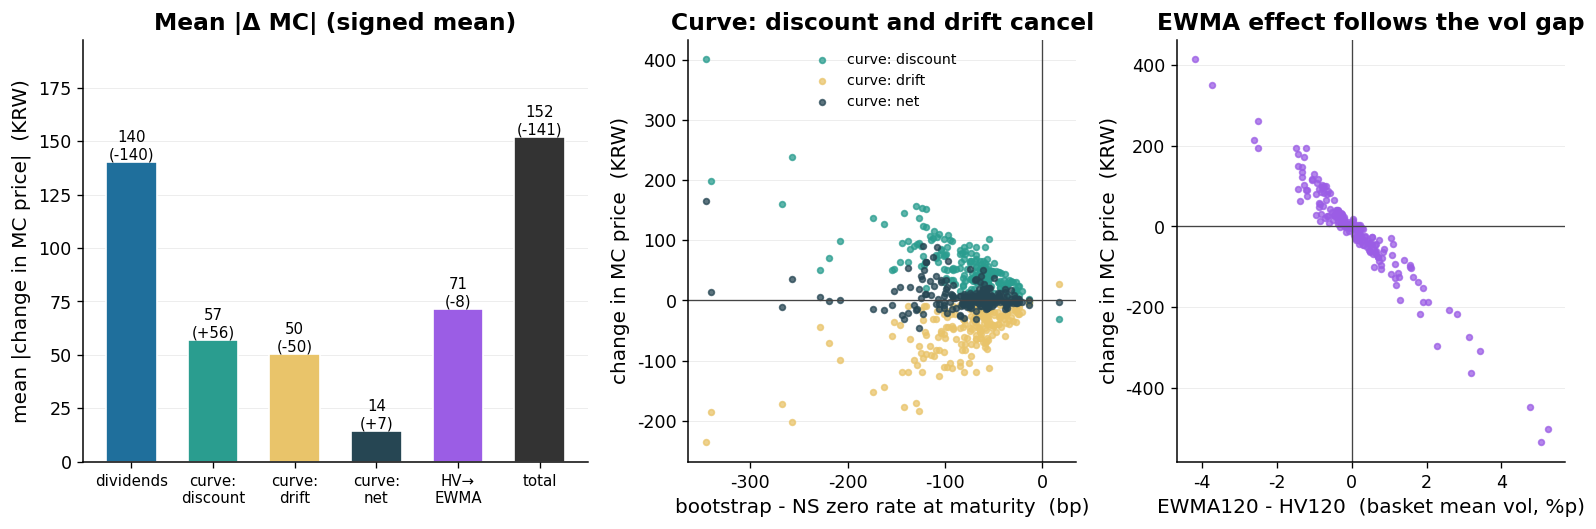

EWMA 효과와 변동성 차이의 상관: -0.97
saved -> mc_boot_decomposition.png


In [6]:
STEPS = {"before: NS · HV120 · q=0": "ns_h120_q0", "+ dividends: NS · HV120 · div": "ns_h120",
         "+ curve: bootstrap · HV120 · div": "bt_h120", "+ EWMA = after: bootstrap · EWMA120 · div": "bt_e120"}
T = pd.DataFrame({lab: {"mean_err_KRW": ((d.fair - d[c]) * FACE).mean(), "MAE_KRW": ((d.fair - d[c]) * FACE).abs().mean()}
                  for lab, c in STEPS.items()}).T
T.to_csv(fm.stat("mc_boot_steps"))
print("=== 단계별 (같은 경로) ==="); print(T.round(1).to_string())

DEC = pd.DataFrame({"dividends": (d.ns_h120 - d.ns_h120_q0) * FACE,
                    "curve: discount": (d.bt_disc_h120 - d.ns_h120) * FACE, "curve: drift": (d.bt_h120 - d.bt_disc_h120) * FACE,
                    "curve: net": (d.bt_h120 - d.ns_h120) * FACE, "HV120 → EWMA120": (d.bt_e120 - d.bt_h120) * FACE,
                    "total": (d.bt_e120 - d.ns_h120_q0) * FACE})
DEC.describe().to_csv(fm.stat("mc_boot_decomposition"))
print("\n=== MC 가격 변화 분해 (원, 음수 = MC 가 싸짐) ===")
print(pd.DataFrame({"mean": DEC.mean(), "mean |Δ|": DEC.abs().mean(), "std": DEC.std()}).round(1).to_string())
for lab, x in [("단기 끝 민감도 (CD 노드 유무)", (d.bt_h120 - d.bt_irs_h120) * FACE),
               ("상관 정의 (영업일 120일 − 3시장 공통거래일 120개)", (d.bt_h120 - d.bt_h120_cc) * FACE)]:
    print(f"{lab}: 평균 {x.mean():+.1f}원, 상품별 |Δ| {x.abs().mean():.1f}원")

dz = (d.bt_zT - d.ns_zT) * 1e4
fig, ax = plt.subplots(1, 3, figsize=(13.333, 4.6), gridspec_kw={"width_ratios": [1.3, 1, 1]})
cols = [AFT, MID, NSC, "#264653", EWC, "#333333"]
absm, sgnm = DEC.abs().mean(), DEC.mean()
ax[0].bar(range(len(DEC.columns)), absm.values, color=cols, edgecolor="white", width=.62)
for j, nm in enumerate(DEC.columns):
    ax[0].text(j, absm[nm], f"{absm[nm]:.0f}\n({sgnm[nm]:+.0f})", ha="center", va="bottom", fontsize=9)
ax[0].set_xticks(range(len(DEC.columns)))
ax[0].set_xticklabels(["dividends", "curve:\ndiscount", "curve:\ndrift", "curve:\nnet", "HV→\nEWMA", "total"], fontsize=9)
ax[0].set_ylim(0, absm.max() * 1.3); ax[0].set_ylabel("mean |change in MC price|  (KRW)")
ax[0].set_title("Mean |Δ MC| (signed mean)")
for nm, col in [("curve: discount", MID), ("curve: drift", NSC), ("curve: net", "#264653")]:
    ax[1].scatter(dz, DEC[nm], s=12, color=col, alpha=.75, label=nm)
ax[1].axhline(0, color="#444", lw=.8); ax[1].axvline(0, color="#444", lw=.8)
ax[1].set_xlabel("bootstrap - NS zero rate at maturity  (bp)"); ax[1].set_ylabel("change in MC price  (KRW)")
ax[1].set_title("Curve: discount and drift cancel"); ax[1].legend(fontsize=8.5)
dv = (d.ew120 - d.hv120) * 100
ax[2].scatter(dv, DEC["HV120 → EWMA120"], s=12, color=EWC, alpha=.75)
ax[2].axhline(0, color="#444", lw=.8); ax[2].axvline(0, color="#444", lw=.8)
ax[2].set_xlabel("EWMA120 - HV120  (basket mean vol, %p)"); ax[2].set_ylabel("change in MC price  (KRW)")
ax[2].set_title("EWMA effect follows the vol gap")
for a in ax:
    a.grid(axis="y", color="#dddddd", lw=.5, alpha=.6)
fig.tight_layout(); fig.savefig(fm.image("mc_boot_decomposition")); plt.show()
print(f"EWMA 효과와 변동성 차이의 상관: {np.corrcoef(dv, DEC['HV120 → EWMA120'])[0, 1]:+.2f}")
print("saved ->", fm.image("mc_boot_decomposition").name)

## 17-6. 시기별 — 개선이 해마다 고른가

배당은 해마다 비슷한 크기로 MC 를 낮추고, 커브 차이는 금리 인상기(2022~2023)에 가장 컸다.
EWMA 는 최근 변동에 더 반응하므로 변동성 레짐이 바뀐 해에 HV120 과 차이가 벌어질 수 있다.

       n  err_bef  err_aft  mae_bef  mae_aft  div_effect  curve_gap_bp  curve_effect  ewma_effect
year                                                                                             
2015  15   -195.0    114.0    552.0    516.0      -271.0         -70.0          -9.0        -30.0
2016  12   -402.0   -306.0    433.0    386.0      -147.0         -79.0           7.0         45.0
2017  17   -757.0   -757.0    799.0    797.0       -37.0         -76.0          34.0          3.0
2018  23   -509.0   -360.0    546.0    453.0      -144.0         -58.0           6.0        -12.0
2019  27   -551.0   -472.0    551.0    472.0      -114.0         -66.0          10.0         24.0
2020  17     95.0    338.0    739.0    847.0      -193.0        -106.0          -7.0        -43.0
2021  24   -951.0   -787.0    955.0    831.0      -159.0         -82.0           2.0         -7.0
2022  19   -792.0   -607.0    828.0    661.0      -137.0        -123.0           5.0        -52.0
2023  19   -753.0   

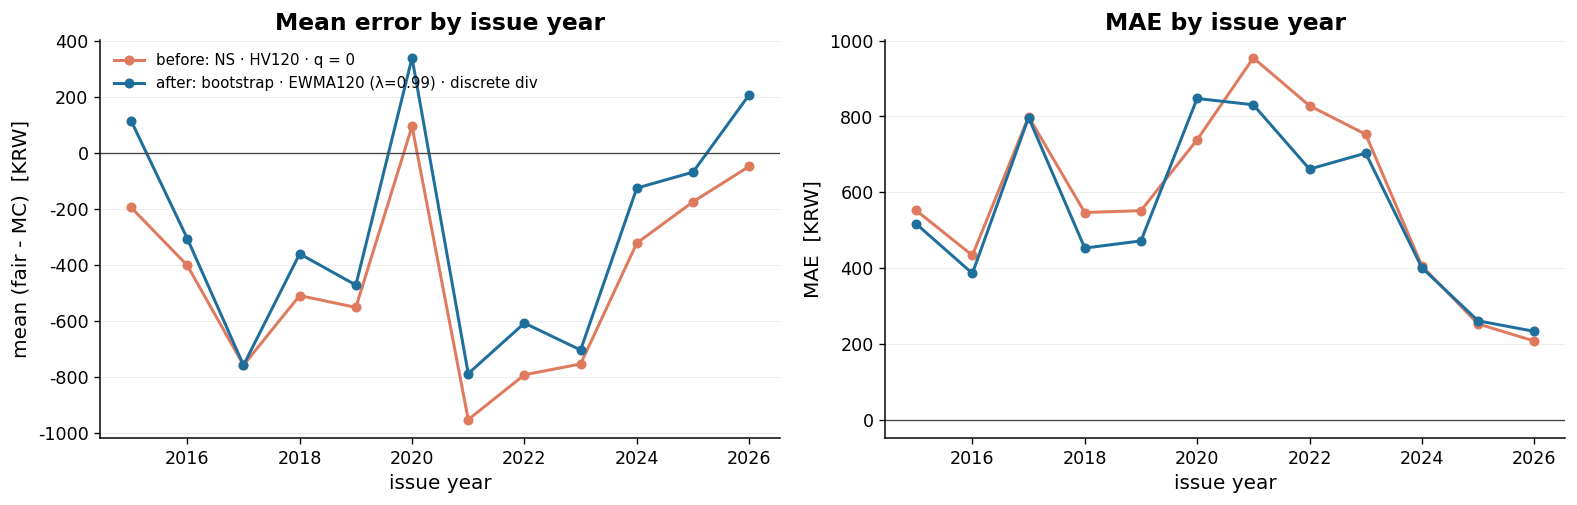

saved -> mc_boot_by_year.png


In [7]:
t = d.groupby("year").agg(n=("fair", "size"), err_bef=("err_bef", "mean"), err_aft=("err_aft", "mean"),
                          mae_bef=("err_bef", lambda s: s.abs().mean()), mae_aft=("err_aft", lambda s: s.abs().mean()))
t["div_effect"] = ((d.ns_h120 - d.ns_h120_q0) * FACE).groupby(d.year).mean()
t["curve_gap_bp"] = ((d.bt_zT - d.ns_zT) * 1e4).groupby(d.year).mean()
t["curve_effect"] = ((d.bt_h120 - d.ns_h120) * FACE).groupby(d.year).mean()
t["ewma_effect"] = ((d.bt_e120 - d.bt_h120) * FACE).groupby(d.year).mean()
t.to_csv(fm.stat("mc_boot_by_year"))
print(t.round(0).to_string())

fig, ax = plt.subplots(1, 2, figsize=(13.333, 4.4))
for a, cb, ca, yl, tt in [(ax[0], "err_bef", "err_aft", "mean (fair - MC)  [KRW]", "Mean error by issue year"),
                          (ax[1], "mae_bef", "mae_aft", "MAE  [KRW]", "MAE by issue year")]:
    a.plot(t.index, t[cb], "o-", ms=5, lw=1.8, color=BEF, label=LB)
    a.plot(t.index, t[ca], "o-", ms=5, lw=1.8, color=AFT, label=LA)
    a.axhline(0, color="#444", lw=.8); a.set_xlabel("issue year"); a.set_ylabel(yl); a.set_title(tt)
    a.grid(axis="y", color="#dddddd", lw=.5, alpha=.6)
ax[0].legend(fontsize=9)
fig.tight_layout(); fig.savefig(fm.image("mc_boot_by_year")); plt.show()
print("saved ->", fm.image("mc_boot_by_year").name)

## 결론 — 편향 감소는 배당 몫이고, 커브 · EWMA 는 거의 기여하지 않는다

200개 상품, 공통난수(같은 경로) 기준.

| | 전: NS · HV120 · q = 0 | 후: 부트스트랩 · EWMA120 · 이산배당 | 변화 (후 − 전) |
|---|---|---|---|
| 평균 오차 (공정가 − MC) | -517원 | -376원 | **+141원** |
| MAE | 641원 | 588원 | **-53원** |
| MAPE | 7.07% | 6.46% | -0.60%p |
| R² (공정가 vs MC) | -1.586 | -1.284 | +0.302 |
| \|오차\| 가 줄어든 상품 | | 77.0% | |
| 가격구간 기울기 (최안전 − 최위험) | 1,030원 | 988원 | -42원 |

1. **후 사양이 전보다 낫다.** 과대평가 편향이 -517 → -376원으로 27% 줄고,
   MAE 도 641 → 588원으로 준다. 77% 의 상품에서 오차가 줄었다.
2. **개선은 거의 전부 배당에서 온다.** 같은 경로로 한 단계씩 바꾸면:

   | 단계 | 평균 오차 | MAE | MC 변화 (평균) |
   |---|---|---|---|
   | 전: NS · HV120 · q = 0 | -517원 | 641원 | |
   | + 이산배당 | -377원 | **571원** | -140원 |
   | + 부트스트랩 커브 | -384원 | 579원 | +6.6원 |
   | + EWMA120 (= 후) | -376원 | 588원 | -7.6원 |

   배당이 편향과 MAE 를 모두 줄이고, 커브와 EWMA 는 편향을 거의 옮기지 않으면서 MAE 를 각각
   +8원, +9원 늘린다.
3. **NS 커브는 ELS 구간을 크게 높게 잡고 있었다.** 상품 만기 제로금리가 부트스트랩보다 평균 80bp 높다
   (1년 50bp, 3년 80bp; 3개월은 -1bp 로 거의 같음). NS 3년이 시장 IRS 3년보다 평균 +80bp 이고,
   82% 의 날짜에서 NS 3년이 NS 자신의 10년 노드와 3개월보다 모두 높다 — 시장에 없는 **1~3년 혹**이다.
   콜 = CD 로 둔 반사실에서는 NS 3년이 2.87% → 2.12% 로 내려와 시장 IRS 3년(2.08%)과 거의 같아진다
   — 콜 − CD 스프레드 19bp 가 약 4배로 증폭된 것이다.
4. **그런데 커브를 바꿔도 가격은 거의 안 바뀐다.** 금리가 80bp 낮아지면 할인이 가격을 +56원 올리고,
   선도가격이 낮아져 조기상환이 늦어지는 드리프트 효과가 -50원 내린다. 순효과는 평균 +6.6원, 상품별 |Δ| 14원.
   커브 차이가 가장 컸던 해(2022년, -123bp)에도 +5원이다. **할인만 바꾸는 것은 일관성이 없는 비교**라 쓰지 않았다.
5. **EWMA120 (λ = 0.99) 은 감쇠를 가장 완만하게 두어도 도움이 안 된다.** 평균 변동성은 거의 같고
   (18.40% → 18.46%) 편향을 -8원만 옮기면서 상품별로 71원씩 흔든다.
   EWMA 효과는 두 변동성 차이를 그대로 따라간다(상관 -0.97) — 최근 수익률에 가중을 더 주는 것이 공정가 설명력을 높이지 않는다.
6. **단기 끝 · 상관 정의는 영향이 없다.** CD 노드를 빼고 IRS 만으로 부트스트랩해도 평균 +0.7원(|Δ| 1.8원),
   상관을 3시장 공통거래일 120개로 잡아도 평균 +0.2원(|Δ| 4.1원).
7. **가격구간 기울기와 시기 변동은 그대로다.** 기울기 1,030 → 988원 — 저가 구간 과대평가(스큐 흔적)는 남는다.
   \|평균 오차\| 가 5원 넘게 커진 해: 2020년 +95 → +338원 (17개), 2026년 -49 → +207원 (4개) — 모두 후 사양에서 MC 가 공정가보다 낮아진(오차 +) 해로, 배당이 MC 를 공정가 아래로 더 밀었다.

**권장**: 배당은 **넣는다**. 커브는 방법론상 **부트스트랩(시장 IRS 재현)** 이 맞고 가격 영향이 작아 바꿔도 결과가 흔들리지 않는다.
변동성은 같은 120일 창이라면 **단순 HV120** 이 EWMA120 보다 MAE 가 9원 낮다.

**한계**: 200개 표본. 단일 커브(CD91) — KOFR OIS 할인은 데이터가 없어 반영하지 않았다(할인 몫은 금리 1bp 당 약 0.70원).
IRS 는 산업은행 1개 딜러 호가 mid (한국자금중개와 0.17~0.27bp 일치). T+1 결제 · 휴일 조정 무시. 해외 지수도 KRW 커브로 드리프트를 잡는
엔진 구조(퀀토 조정 없음)는 그대로다. IRS 기준일은 발행일 1~7일 전(중앙값 1일).